In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import math
from scipy.optimize import fsolve

In [2]:
df_raw = pd.read_csv("data/icecube_public.txt")

In [3]:
col_str = str(list(df_raw.columns)[0])
col_headers = col_str.split()[1:]
data_cols = ['MJD[days]','log10(E/GeV)','AngErr[deg]', 'RA[deg]', 'Dec[deg]']
df_stripped = df_raw[col_str].str.strip()
is_numeric = df_stripped.str.match(r"\d+")
df_string = df_stripped[is_numeric]

In [4]:
df = pd.DataFrame()
df[col_headers] = df_string.str.split("\s+", expand=True)
df = df.astype(float)

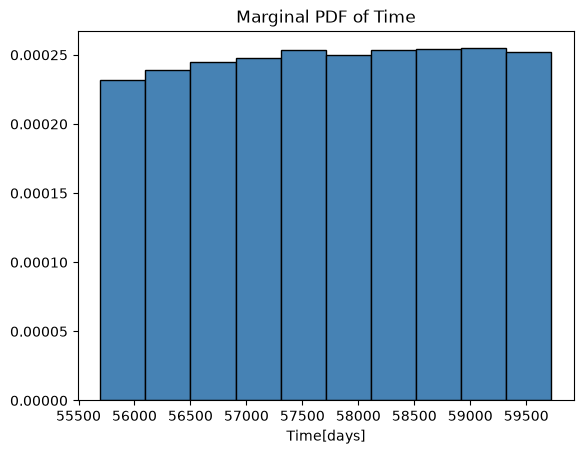

In [5]:
plt.hist(df["MJD[days]"], density=True,edgecolor = "black", color="steelblue")
plt.xlabel("Time[days]")
plt.title("Marginal PDF of Time")
plt.show()

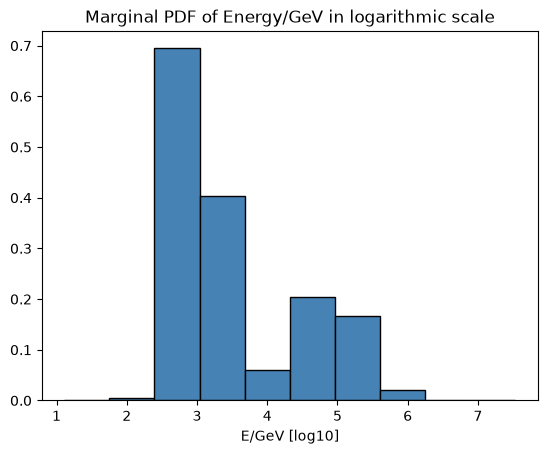

In [6]:
plt.hist(df["log10(E/GeV)"], density=True,color="steelblue",edgecolor = "black")
plt.xlabel("E/GeV [log10]")
plt.title("Marginal PDF of Energy/GeV in logarithmic scale")
plt.show()

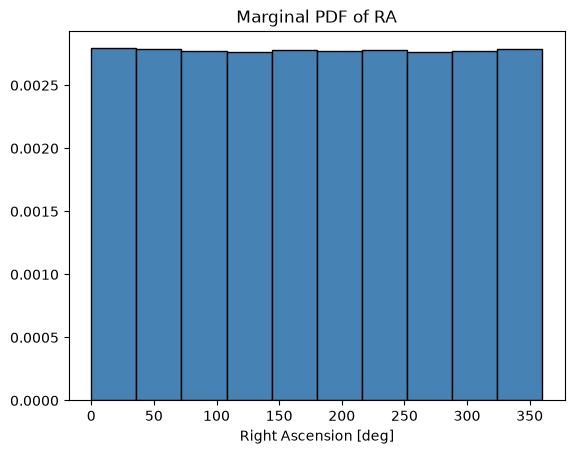

In [7]:
plt.hist(df["RA[deg]"], density=True,color="steelblue",edgecolor = "black")
plt.xlabel("Right Ascension [deg]")
plt.title("Marginal PDF of RA")
plt.show()

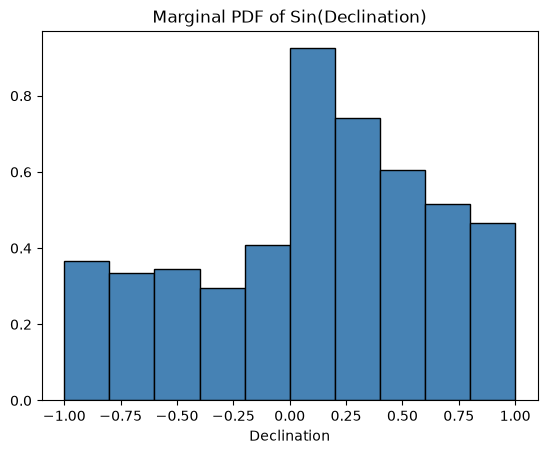

In [8]:
plt.hist(np.sin(df["Dec[deg]"]*np.pi/180), density=True,color="steelblue",edgecolor = "black")
plt.xlabel("Declination")
plt.title("Marginal PDF of Sin(Declination)")
plt.show()

We care about sin(declination) instead of declination because it represents a physical ratio of how much sky we see and in what direction relative to the radius of the earth. Also in pure degrees or radians, we may see effects of earth geometry in the results, there is a larger solid angle around the equator than the poles, we do not want to be biased to that. 

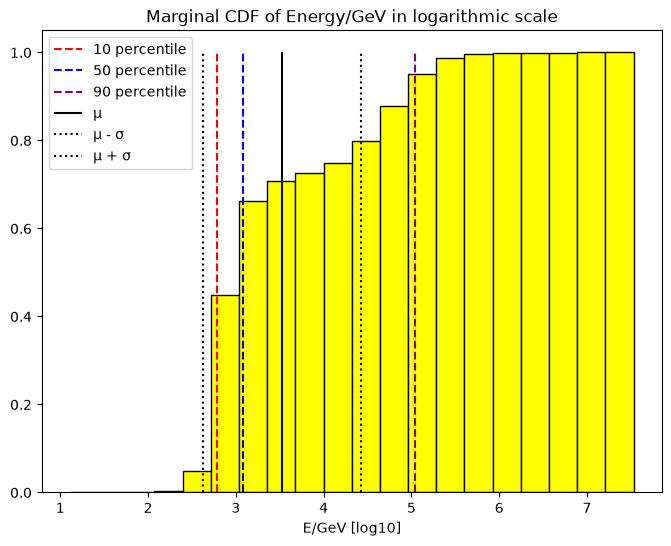

In [9]:
plt.figure(figsize=(8, 6))
for i,c in zip([10,50,90],["red","blue","purple"]):
    plt.vlines(np.percentile(df["log10(E/GeV)"],i), 
               ymin=0, ymax=1, colors=c, linestyle="dashed", label=f"{i} percentile")

plt.vlines(np.mean(df["log10(E/GeV)"]), ymin=0, ymax=1, colors= "black", linestyle="solid", label="\u03bc")
plt.vlines(np.mean(df["log10(E/GeV)"]) - np.std(df["log10(E/GeV)"]), ymin=0, ymax=1, colors= "black", linestyle=":", label="\u03bc - \u03C3")
plt.vlines(np.mean(df["log10(E/GeV)"]) + np.std(df["log10(E/GeV)"]), ymin=0, ymax=1, colors= "black", linestyle=":", label="\u03bc + \u03C3")

plt.hist(df["log10(E/GeV)"], bins=20, density=True, color="yellow" ,edgecolor = "black", cumulative=True)

plt.xlabel("E/GeV [log10]")
plt.title("Marginal CDF of Energy/GeV in logarithmic scale")
plt.legend()
plt.show()

In [10]:
time = np.array(df["MJD[days]"])*86400

In [11]:
time_diff = time[1:] - time[:-1]
time_diff_positive = time_diff[time_diff > 0]
time_diff_1000 = time_diff_positive[time_diff_positive <= 1000]

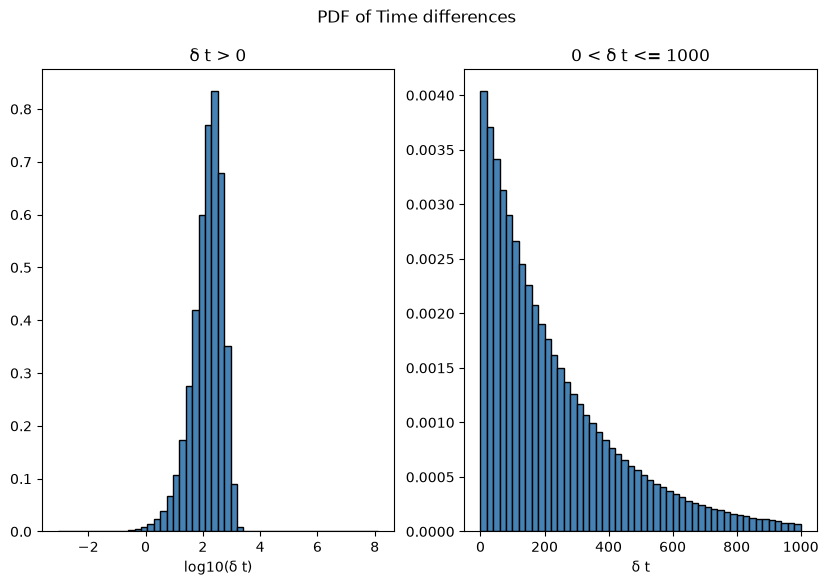

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,6))
fig.suptitle('PDF of Time differences')
ax1.hist(np.log10(time_diff_positive), bins=50, edgecolor="black", color="steelblue", density=True)
ax2.hist(time_diff_1000, bins=50, edgecolor="black", color="steelblue", density=True)
ax1.set_title("\u03B4 t > 0")
ax2.set_title("0 < \u03B4 t <= 1000")
ax1.set_xlabel("log10(\u03B4 t)")
ax2.set_xlabel("\u03B4 t")
plt.show()

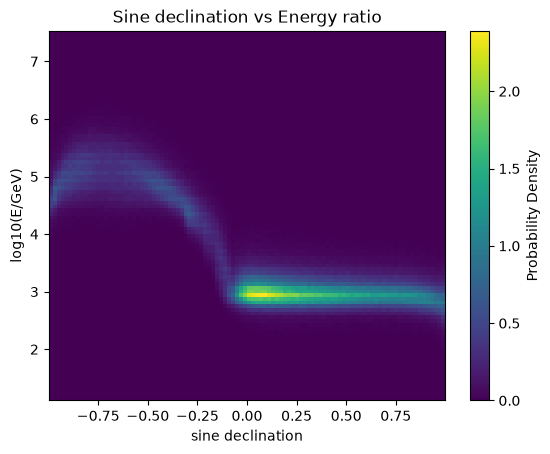

In [13]:
sin_dec = np.sin(df["Dec[deg]"]*(np.pi/180))
E_per_GeV = df["log10(E/GeV)"]
plt.hist2d(sin_dec, E_per_GeV ,bins=100, density=True)
plt.xlabel("sine declination")
plt.ylabel("log10(E/GeV)")
plt.title("Sine declination vs Energy ratio")
plt.colorbar(label="Probability Density")
plt.show()

In [14]:
def solve_theta(latitude, tolerance, max_steps = 30):
    error_flag = np.abs(np.abs(latitude) - np.pi/2) <= tolerance
    theta = latitude.copy()
    theta[error_flag] = 0
    theta_func = lambda x : x - ((2*x + np.sin(2*x) - np.pi*np.sin(latitude))/(2 + 2*np.cos(2*x)))

    diff = np.abs(theta_func(theta) - theta)

    steps = 0
    while((np.max(diff[~error_flag]) >= tolerance) and (steps < max_steps)):
        theta_new = theta_func(theta)
        diff = np.abs(theta_new - theta)
        theta = theta_new
        steps += 1

    theta[error_flag] = latitude[error_flag]
    return theta

    
def mollewide_proj(longitude, latitude, R, central_meredian = 180):
    delta_longitude = (longitude - central_meredian + 180) % 360 - 180
    latitude = latitude * np.pi/180
    delta_longitude *= np.pi/180
    theta_solution = solve_theta(latitude, tolerance = 1e-8)   
    x = (R*2*np.sqrt(2)/np.pi)*delta_longitude*np.cos(theta_solution)
    y = R*np.sqrt(2)*np.sin(theta_solution)
    return x,y

In [18]:
x,y = mollewide_proj(df["RA[deg]"], df["Dec[deg]"], R=6371000)

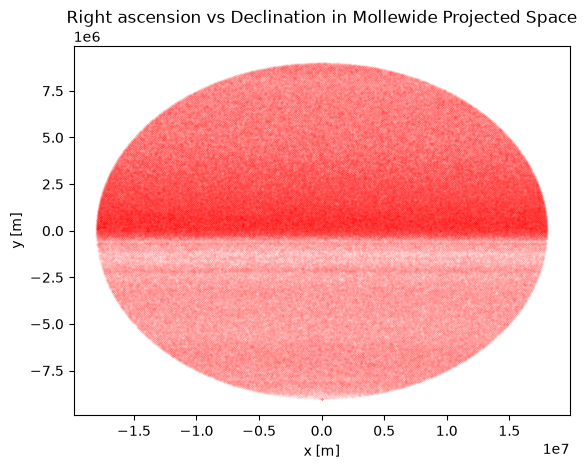

In [25]:
plt.scatter(x,y,s=0.0001, c="red")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Right ascension vs Declination in Mollewide Projected Space")
plt.show()

If we want to plot the declination againt Right Ascension as a scatter plot, we are plotting in flat space. While the units match, we can get more information if we standardize them to x,y as a projection. 

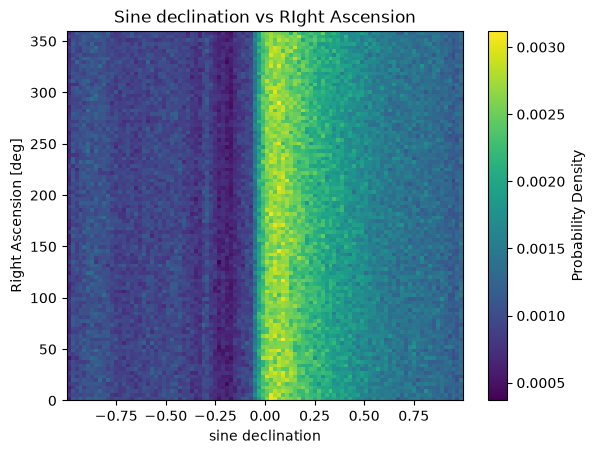

In [26]:
sin_dec = np.sin(df["Dec[deg]"]*(np.pi/180))
RA = df["RA[deg]"]
plt.hist2d(sin_dec, RA ,bins=100, density=True)
plt.xlabel("sine declination")
plt.ylabel("Right Ascension [deg]")
plt.title("Sine declination vs RIght Ascension ")
plt.colorbar(label="Probability Density")
plt.show()

In [105]:
df_corr = df[["log10(E/GeV)", "Dec[deg]"]]
df_north = df_corr[df_corr["Dec[deg]"] > -5]
df_south = df_corr[df_corr["Dec[deg]"] < -5]

df_corr_north = df_north.copy()
df_corr_south = df_south.copy()

In [106]:
df_corr_north["Dec[deg]"] = np.sin(df_north["Dec[deg]"])
df_corr_north.corr()

,log10(E/GeV),Dec[deg]
log10(E/GeV),1.000000,0.000123
Dec[deg],0.000123,1.000000


In [107]:
df_corr_south["Dec[deg]"] = np.sin(df_south["Dec[deg]"])
df_corr_south.corr()

,log10(E/GeV),Dec[deg]
log10(E/GeV),1.000000,-0.004586
Dec[deg],-0.004586,1.000000


Random Declinations: -51.542, -31.653


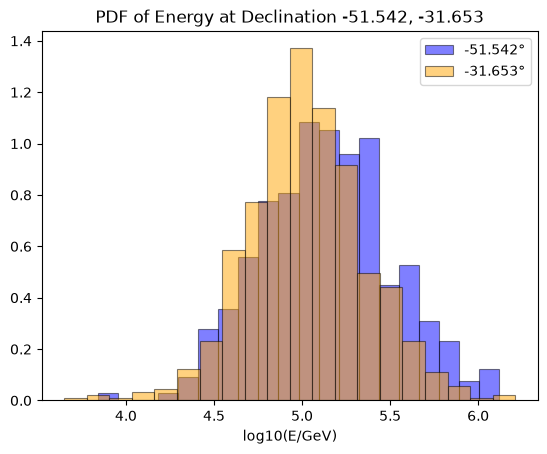

In [108]:
dec1, dec2 = np.random.choice(df_south["Dec[deg]"], size=2)
print(f"Random Declinations: {dec1}, {dec2}")
dec1_flag = (df_south["Dec[deg]"] > (dec1- 0.05)) & (df_south["Dec[deg]"] < (dec1 + 0.05))
dec2_flag = (df_south["Dec[deg]"] > (dec2- 0.05)) & (df_south["Dec[deg]"] < (dec2 + 0.05))
plt.hist(df_south[dec1_flag]["log10(E/GeV)"], bins=20, edgecolor="black", color="blue", 
         alpha=0.5, linewidth=0.8, density=True, label=f"{dec1}°")
plt.hist(df_south[dec2_flag]["log10(E/GeV)"], bins=20, edgecolor="black", color="orange",
         alpha=0.5, linewidth=0.8, density=True, label=f"{dec2}°")
plt.xlabel("log10(E/GeV)")
plt.title(f"PDF of Energy at Declination {dec1}, {dec2}")
plt.legend()
plt.show()

Sin(Declination) vs Energy shows us that events are more "mono-energetic" coming from the north sky vs the south sky which has a larger range of energies. There is also a noticable difference in the number of events we see recorded from the north sky vs the south sky. I beleive this is due to the fact that the the earth filters events coming from the north sky, so we can be confident the interactions are neutrinos. THe southern sky is limited by our reconstruction quality and confidence that an event is a neutrino event.  